# Coincidencia espacial y temporal entre MIRA y FIRMS

Este notebook evalúa si los 113 incendios registrados en el CSV MIRA tienen detecciones FIRMS compatibles en distintas ventanas temporales y espaciales. Los umbrales son escenarios de sensibilidad exploratorios, no criterios oficiales de correspondencia.

In [1]:
from pathlib import Path
import re
import unicodedata

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RUTA_MIRA = Path("incendios_forestales_mira_0.csv")
RUTA_FIRMS_PUNTOS = Path("results/data/firms_uruguay_asignadas.parquet")
RUTA_FIRMS_SEMANAL = Path("results/data/firms_departamento_semana_clean.parquet")
RUTA_LIMITES = Path("geoBoundaries-URY-ADM1-all/geoBoundaries-URY-ADM1.geojson")
for ruta in [RUTA_MIRA, RUTA_FIRMS_PUNTOS, RUTA_FIRMS_SEMANAL, RUTA_LIMITES]:
    assert ruta.exists(), f"No se encontró {ruta}"
mira = pd.read_csv(RUTA_MIRA, encoding="utf-8-sig")
firms = pd.read_parquet(RUTA_FIRMS_PUNTOS)
limites = gpd.read_file(RUTA_LIMITES).to_crs("EPSG:4326")

## 1. Fuentes y granularidad

Se utiliza `results/data/firms_uruguay_asignadas.parquet`, la fuente FIRMS con mayor granularidad procesada disponible: una fila por detección asignada, con fecha y hora de adquisición, coordenadas y departamento. Contiene 8.518 detecciones de 2018–2025. Los siete puntos sin departamento documentados por el pipeline no forman parte de este archivo. El panel semanal se usa después, únicamente como contraste agregado.

In [2]:
inventario = pd.DataFrame({
    "fuente": ["MIRA", "FIRMS puntual asignado"],
    "ruta": [str(RUTA_MIRA), str(RUTA_FIRMS_PUNTOS)],
    "filas": [len(mira), len(firms)],
    "columnas": [mira.shape[1], firms.shape[1]],
    "duplicados_exactos": [int(mira.duplicated().sum()), int(firms.duplicated().sum())],
})
display(inventario)
print("Columnas MIRA:", mira.columns.tolist())
print("Columnas FIRMS:", firms.columns.tolist())

,fuente,ruta,filas,columnas,duplicados_exactos
0,MIRA,incendios_forestales_mira_0.csv,113,14,0
1,FIRMS puntual asignado,results/data/firms_uruguay_asignadas.parquet,8518,24,0


Columnas MIRA: ['ObjectID', 'GlobalID', 'Número de informe MIRA', 'Tipo de incendio', 'Fecha de registro del evento', 'Departamento', 'Fuente', 'Área', 'CreationDate', 'Creator', 'EditDate', 'Editor', 'x', 'y']
Columnas FIRMS: ['latitud', 'longitud', 'brillo_ti4', 'scan', 'track', 'fecha_adq', 'hora_adq_hhmm', 'satelite', 'instrumento', 'confianza_raw', 'version', 'brillo_ti5', 'potencia_radiativa', 'dia_noche', 'type', 'pais', 'pais_codigo', 'confianza_num', 'hora_adq', 'es_diurno', 'fecha', 'departamento', 'departamento_iso', 'shapeID']


## 2. Normalización temporal y espacial

Las coordenadas de ambos archivos se interpretan en EPSG:4326. La hora MIRA no incluye zona horaria explícita y la hora de adquisición FIRMS tampoco se armoniza aquí con una zona local. Para evitar precisión artificial, las ventanas se calculan por **fecha calendario**, no por diferencia horaria exacta. Los datos originales se conservan en memoria sin sobrescribir sus columnas.

In [3]:
FORMATO_MIRA = "%m/%d/%Y %I:%M:%S %p"
mira["fecha_hora_mira"] = pd.to_datetime(mira["Fecha de registro del evento"], format=FORMATO_MIRA, errors="coerce")
mira["fecha_mira"] = mira["fecha_hora_mira"].dt.normalize()
firms["fecha_firms"] = pd.to_datetime(firms["fecha"], errors="coerce").dt.normalize()
hora_hhmm = firms["hora_adq_hhmm"].astype("string").str.zfill(4)
firms["fecha_hora_firms_sin_zona"] = pd.to_datetime(
    firms["fecha_firms"].dt.strftime("%Y-%m-%d") + " " + hora_hhmm,
    format="%Y-%m-%d %H%M", errors="coerce")
def normalizar_departamento(valor):
    texto = unicodedata.normalize("NFKD", str(valor)).encode("ascii", "ignore").decode().lower()
    return re.sub(r"[^a-z]", "", texto)
mira["departamento_normalizado"] = mira["Departamento"].map(normalizar_departamento)
firms["departamento_normalizado"] = firms["departamento"].map(normalizar_departamento)
mira["fecha_inicio_semana"] = mira["fecha_mira"] - pd.to_timedelta(mira["fecha_mira"].dt.weekday, unit="D")
firms["fecha_inicio_semana"] = firms["fecha_firms"] - pd.to_timedelta(firms["fecha_firms"].dt.weekday, unit="D")
assert mira["fecha_hora_mira"].notna().all()
assert firms[["fecha_firms", "fecha_hora_firms_sin_zona"]].notna().all().all()

In [4]:
calidad = pd.DataFrame({
    "fuente": ["MIRA", "FIRMS"],
    "fecha_min": [mira["fecha_mira"].min(), firms["fecha_firms"].min()],
    "fecha_max": [mira["fecha_mira"].max(), firms["fecha_firms"].max()],
    "latitud_nula": [mira["y"].isna().sum(), firms["latitud"].isna().sum()],
    "longitud_nula": [mira["x"].isna().sum(), firms["longitud"].isna().sum()],
    "coordenadas_fuera_rango_global": [
        (~mira["y"].between(-90, 90) | ~mira["x"].between(-180, 180)).sum(),
        (~firms["latitud"].between(-90, 90) | ~firms["longitud"].between(-180, 180)).sum(),
    ],
    "duplicados_exactos": [mira.duplicated().sum(), firms.duplicated().sum()],
    "departamentos": [mira["departamento_normalizado"].nunique(), firms["departamento_normalizado"].nunique()],
})
display(calidad)
puntos_mira = gpd.GeoDataFrame(mira.copy(), geometry=gpd.points_from_xy(mira["x"], mira["y"]), crs="EPSG:4326")
revision_mira = gpd.sjoin(puntos_mira, limites[["shapeName", "geometry"]], how="left", predicate="within")
revision_mira["coincide_departamento"] = revision_mira["departamento_normalizado"].eq(revision_mira["shapeName"].map(normalizar_departamento))
print("MIRA sin departamento espacial por within:", int(revision_mira["shapeName"].isna().sum()))
print("MIRA con discrepancia entre departamento declarado y espacial:", int((revision_mira["shapeName"].notna() & ~revision_mira["coincide_departamento"]).sum()))
display(revision_mira.loc[revision_mira["shapeName"].isna() | ~revision_mira["coincide_departamento"], ["Número de informe MIRA", "Departamento", "shapeName", "x", "y"]])
inicio_comun = max(mira["fecha_mira"].min(), firms["fecha_firms"].min())
fin_comun = min(mira["fecha_mira"].max(), firms["fecha_firms"].max())
mira_comun = mira.loc[mira["fecha_mira"].between(inicio_comun, fin_comun)].copy()
firms_comun = firms.loc[firms["fecha_firms"].between(inicio_comun - pd.Timedelta(days=7), fin_comun + pd.Timedelta(days=7))].copy()
print("Período común:", inicio_comun.date(), "a", fin_comun.date())
print("Eventos MIRA en período común:", len(mira_comun), "de", len(mira))
print("CRS utilizado para coordenadas:", limites.crs)

,fuente,fecha_min,fecha_max,latitud_nula,longitud_nula,coordenadas_fuera_rango_global,duplicados_exactos,departamentos
0,MIRA,2018-04-08,2022-06-26,0,0,0,0,19
1,FIRMS,2018-01-02,2025-12-31,0,0,0,0,19


MIRA sin departamento espacial por within: 1
MIRA con discrepancia entre departamento declarado y espacial: 3


,Número de informe MIRA,Departamento,shapeName,x,y
7,974,Colonia,Montevideo,-56.138247,-34.898600
44,819,Montevideo,NaN,-56.333672,-34.886254
82,503,Tacuarembo,Durazno,-56.488404,-32.810633
83,506,Lavalleja,Treinta y Tres,-54.532322,-33.411166


Período común: 2018-04-08 a 2022-06-26
Eventos MIRA en período común: 113 de 113
CRS utilizado para coordenadas: EPSG:4326


## 3. Tabla de pares potenciales

Se generan pares MIRA–FIRMS solo cuando la diferencia entre fechas es de hasta siete días. La distancia geodésica se calcula con Haversine. Un mismo punto FIRMS puede ser compatible con más de un evento MIRA y viceversa; no se fuerza una asignación uno-a-uno. Los resultados son conteos por evento, por lo que no se duplican eventos al calcular porcentajes.

In [5]:
def distancia_haversine_km(latitud, longitud, latitudes, longitudes):
    lat1, lon1 = np.radians(float(latitud)), np.radians(float(longitud))
    lat2, lon2 = np.radians(np.asarray(latitudes, dtype=float)), np.radians(np.asarray(longitudes, dtype=float))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371.0088 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
pares = []
for indice_mira, evento in mira_comun.iterrows():
    diferencia = (firms_comun["fecha_firms"] - evento["fecha_mira"]).dt.days
    mascara = diferencia.abs().le(7)
    candidatas = firms_comun.loc[mascara]
    distancias = distancia_haversine_km(evento["y"], evento["x"], candidatas["latitud"], candidatas["longitud"])
    for indice_firms, delta, distancia in zip(candidatas.index, diferencia.loc[mascara], distancias):
        pares.append({
            "indice_mira": indice_mira, "indice_firms": indice_firms,
            "diferencia_dias": int(delta), "distancia_km": float(distancia),
            "mismo_departamento": evento["departamento_normalizado"] == firms_comun.at[indice_firms, "departamento_normalizado"],
        })
pares = pd.DataFrame(pares)
print("Pares potenciales dentro de ±7 días:", len(pares))
display(pares.head())

Pares potenciales dentro de ±7 días: 16537


,indice_mira,indice_firms,diferencia_dias,distancia_km,mismo_departamento
0,0,5122,-7,175.539853,False
1,0,5123,-7,236.941738,False
2,0,5124,-7,294.113937,False
3,0,5125,-7,302.627746,False
4,0,5126,-6,501.036099,False


## 4. Coincidencia temporal dentro del mismo departamento

In [6]:
resultados_temporales = []
conteos_temporales = {}
for dias, etiqueta in [(0, "Mismo día"), (1, "±1 día"), (3, "±3 días"), (7, "±7 días")]:
    seleccion = pares.loc[pares["mismo_departamento"] & pares["diferencia_dias"].abs().le(dias)]
    conteos = seleccion.groupby("indice_mira").size().reindex(mira_comun.index, fill_value=0)
    conteos_temporales[etiqueta] = conteos
    resultados_temporales.append({
        "ventana": etiqueta, "eventos_con_coincidencia": int(conteos.gt(0).sum()),
        "eventos_sin_coincidencia": int(conteos.eq(0).sum()),
        "porcentaje": conteos.gt(0).mean() * 100,
        "detecciones_asociadas": int(conteos.sum()),
        "mediana_por_evento_coincidente": conteos[conteos.gt(0)].median(),
    })
misma_semana = []
for indice, evento in mira_comun.iterrows():
    misma_semana.append(((firms["departamento_normalizado"] == evento["departamento_normalizado"]) & (firms["fecha_inicio_semana"] == evento["fecha_inicio_semana"])).sum())
conteos_semana = pd.Series(misma_semana, index=mira_comun.index)
resultados_temporales.append({
    "ventana": "Misma semana", "eventos_con_coincidencia": int(conteos_semana.gt(0).sum()),
    "eventos_sin_coincidencia": int(conteos_semana.eq(0).sum()),
    "porcentaje": conteos_semana.gt(0).mean() * 100,
    "detecciones_asociadas": int(conteos_semana.sum()),
    "mediana_por_evento_coincidente": conteos_semana[conteos_semana.gt(0)].median(),
})
tabla_temporal = pd.DataFrame(resultados_temporales)
display(tabla_temporal.round(2))

,ventana,eventos_con_coincidencia,eventos_sin_coincidencia,porcentaje,detecciones_asociadas,mediana_por_evento_coincidente
0,Mismo día,38,75,33.63,128,2.0
1,±1 día,54,59,47.79,405,2.0
2,±3 días,76,37,67.26,875,2.5
3,±7 días,82,31,72.57,1539,5.0
4,Misma semana,73,40,64.60,922,2.0


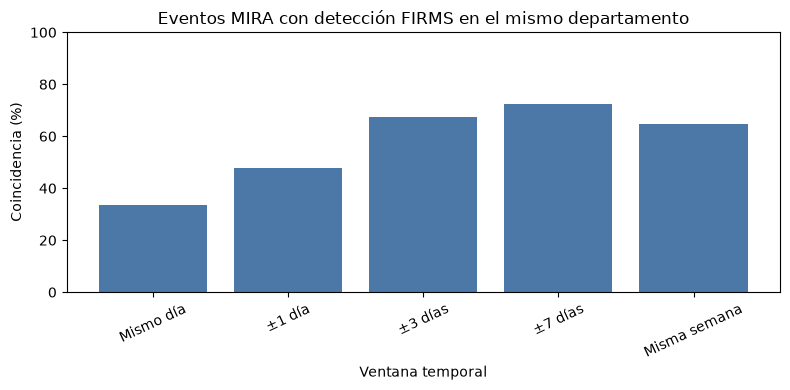

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tabla_temporal["ventana"], tabla_temporal["porcentaje"], color="#4c78a8")
ax.set(title="Eventos MIRA con detección FIRMS en el mismo departamento", xlabel="Ventana temporal", ylabel="Coincidencia (%)", ylim=(0, 100))
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 5. Sensibilidad temporal y espacialLos escenarios siguientes no exigen igualdad departamental: la distancia ya expresa proximidad y evita perder coincidencias próximas a límites administrativos.

In [8]:
escenarios = [(0, 1), (0, 5), (0, 10), (1, 5), (1, 10), (3, 10), (3, 25), (7, 25)]
resultados_espaciales = []
conteos_escenarios = {}
for dias, kilometros in escenarios:
    etiqueta = f"±{dias} día(s), ≤{kilometros} km" if dias else f"Mismo día, ≤{kilometros} km"
    seleccion = pares.loc[pares["diferencia_dias"].abs().le(dias) & pares["distancia_km"].le(kilometros)]
    conteos = seleccion.groupby("indice_mira").size().reindex(mira_comun.index, fill_value=0)
    conteos_escenarios[(dias, kilometros)] = conteos
    resultados_espaciales.append({
        "escenario": etiqueta, "dias": dias, "distancia_km": kilometros,
        "eventos_con_coincidencia": int(conteos.gt(0).sum()),
        "eventos_sin_coincidencia": int(conteos.eq(0).sum()),
        "porcentaje": conteos.gt(0).mean() * 100,
        "detecciones_asociadas": int(conteos.sum()),
    })
tabla_espacial = pd.DataFrame(resultados_espaciales)
display(tabla_espacial.round(2))

,escenario,dias,distancia_km,eventos_con_coincidencia,eventos_sin_coincidencia,porcentaje,detecciones_asociadas
0,"Mismo día, ≤1 km",0,1,7,106,6.19,10
1,"Mismo día, ≤5 km",0,5,17,96,15.04,45
2,"Mismo día, ≤10 km",0,10,22,91,19.47,57
3,"±1 día(s), ≤5 km",1,5,23,90,20.35,84
4,"±1 día(s), ≤10 km",1,10,29,84,25.66,134
5,"±3 día(s), ≤10 km",3,10,36,77,31.86,343
6,"±3 día(s), ≤25 km",3,25,55,58,48.67,591
7,"±7 día(s), ≤25 km",7,25,62,51,54.87,1057


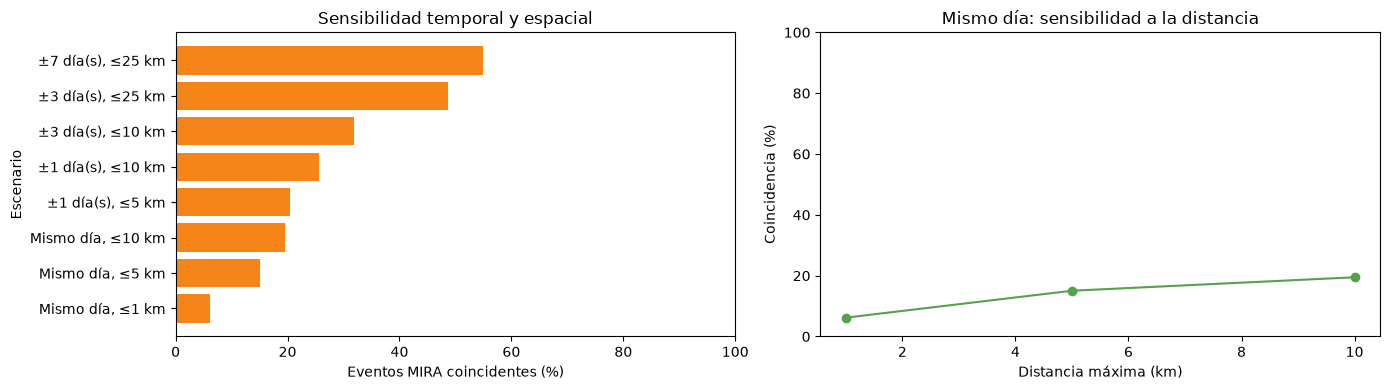

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(tabla_espacial["escenario"], tabla_espacial["porcentaje"], color="#f58518")
axes[0].set(title="Sensibilidad temporal y espacial", xlabel="Eventos MIRA coincidentes (%)", ylabel="Escenario", xlim=(0, 100))
mismo_dia = tabla_espacial.loc[tabla_espacial["dias"].eq(0)]
axes[1].plot(mismo_dia["distancia_km"], mismo_dia["porcentaje"], marker="o", color="#54a24b")
axes[1].set(title="Mismo día: sensibilidad a la distancia", xlabel="Distancia máxima (km)", ylabel="Coincidencia (%)", ylim=(0, 100))
plt.tight_layout()
plt.show()

## 6. Detalle por eventoLa detección más cercana se selecciona entre las candidatas dentro de ±7 días. `detecciones_cercanas_7d_25km` cuenta todas las detecciones compatibles con ese umbral. No constituye una asignación exclusiva entre fuentes.

In [10]:
ordenados = pares.sort_values(["indice_mira", "distancia_km", "diferencia_dias"], key=lambda s: s.abs() if s.name == "diferencia_dias" else s)
mas_cercana = ordenados.drop_duplicates("indice_mira").set_index("indice_mira")
conteo_cercano = pares.loc[pares["distancia_km"].le(25)].groupby("indice_mira").size()
detalle = mira_comun[["Número de informe MIRA", "fecha_mira", "Departamento", "Tipo de incendio", "Fuente", "x", "y"]].copy()
detalle = detalle.join(mas_cercana[["indice_firms", "distancia_km", "diferencia_dias"]])
detalle["fecha_firms_mas_cercana"] = detalle["indice_firms"].map(firms_comun["fecha_firms"])
detalle["detecciones_cercanas_7d_25km"] = conteo_cercano.reindex(detalle.index, fill_value=0).astype(int)
detalle["coincide_3d_25km"] = conteos_escenarios[(3, 25)].gt(0)
display(detalle.sort_values(["coincide_3d_25km", "distancia_km"], ascending=[False, True]))

,Número de informe MIRA,fecha_mira,Departamento,Tipo de incendio,Fuente,x,y,indice_firms,distancia_km,diferencia_dias,fecha_firms_mas_cercana,detecciones_cercanas_7d_25km,coincide_3d_25km
25,852,2022-01-09,Montevideo,Interface_Urbana,prensa,-56.278069,-34.873717,5017,0.127875,6,2022-01-15,21,True
50,821,2021-12-28,Paysandu,Forestal_Plantado,cecoed,-57.552119,-32.413668,4769,0.240007,3,2021-12-31,139,True
92,546,2020-05-16,Rocha,Forestal_Plantado,cecoed,-53.577371,-34.044071,2664,0.246105,0,2020-05-16,2,True
9,970,2022-01-14,Rocha,De_Campo,sgsp,-53.762969,-33.247952,5006,0.394405,0,2022-01-14,1,True
66,773,2021-11-22,Maldonado,Forestal_Plantado,prensa,-55.381061,-34.766331,4579,0.395957,0,2021-11-22,4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,953,2022-01-06,Colonia,De_Campo,sgsp,-58.320667,-33.876742,4928,111.697472,-5,2022-01-01,0,False
94,797,2021-12-09,Salto,Interface_Urbana,sgsp,-57.983374,-31.399052,4603,150.108770,-7,2021-12-02,0,False
14,856,2022-01-13,Salto,De_Campo,cecoed,-57.639346,-31.382221,5005,153.977160,1,2022-01-14,0,False
13,857,2022-01-13,Salto,Interface_Urbana,cecoed,-57.929454,-31.373574,5005,174.735211,1,2022-01-14,0,False


## 7. Coincidencia por año, departamento, tipo, fuente y mesPara estas comparaciones se adopta como referencia descriptiva **±3 días y ≤25 km**. La elección no convierte el escenario en una regla oficial; ofrece tolerancia temporal y espacial intermedia dentro de la grilla solicitada.

In [11]:
mira_perfiles = mira_comun.copy()
mira_perfiles["coincide_referencia"] = conteos_escenarios[(3, 25)].gt(0)
mira_perfiles["anio"] = mira_perfiles["fecha_mira"].dt.year
mira_perfiles["mes"] = mira_perfiles["fecha_mira"].dt.month
def tasa_por(columna):
    return mira_perfiles.groupby(columna, dropna=False)["coincide_referencia"].agg(eventos="size", coincidentes="sum", porcentaje="mean").assign(porcentaje=lambda d: d["porcentaje"] * 100)
tablas_perfil = {columna: tasa_por(columna) for columna in ["anio", "Departamento", "Tipo de incendio", "Fuente", "mes"]}
for nombre, tabla in tablas_perfil.items():
    print("\n", nombre)
    display(tabla.round(2))


 anio


,eventos,coincidentes,porcentaje
anio,,,
2018,1,0,0.00
2019,1,1,100.00
2020,14,11,78.57
2021,46,25,54.35
2022,51,18,35.29



 Departamento


,eventos,coincidentes,porcentaje
Departamento,,,
Artigas,1,0,0.00
Canelones,11,10,90.91
Cerro_Largo,6,3,50.00
Colonia,5,2,40.00
Durazno,2,0,0.00
Flores,11,1,9.09
Florida,7,2,28.57
Lavalleja,9,7,77.78
Maldonado,9,7,77.78



 Tipo de incendio


,eventos,coincidentes,porcentaje
Tipo de incendio,,,
De_Campo,55,24,43.64
Forestal_Nativo,1,1,100.00
Forestal_Plantado,24,12,50.00
Interface_Urbana,33,18,54.55



 Fuente


,eventos,coincidentes,porcentaje
Fuente,,,
cecoed,38,19,50.00
prensa,13,11,84.62
sgsp,62,25,40.32



 mes


,eventos,coincidentes,porcentaje
mes,,,
1,48,22,45.83
2,7,6,85.71
3,1,0,0.00
4,4,0,0.00
5,1,1,100.00
6,6,1,16.67
11,3,2,66.67
12,43,23,53.49


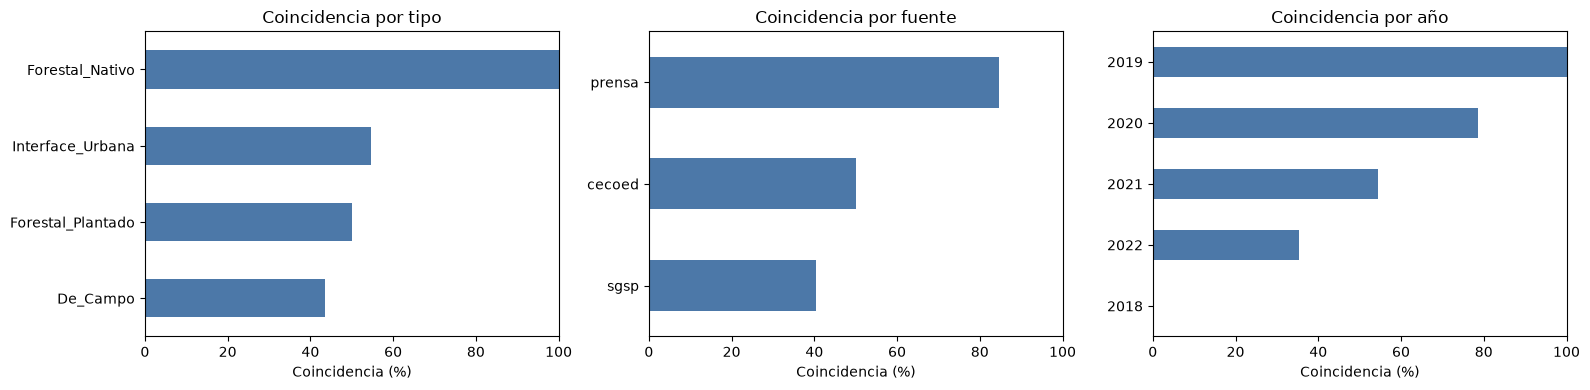

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, columna, titulo in zip(axes, ["Tipo de incendio", "Fuente", "anio"], ["Coincidencia por tipo", "Coincidencia por fuente", "Coincidencia por año"]):
    tabla = tablas_perfil[columna].sort_values("porcentaje")
    tabla["porcentaje"].plot.barh(ax=ax, color="#4c78a8")
    ax.set(title=titulo, xlabel="Coincidencia (%)", ylabel="", xlim=(0, 100))
plt.tight_layout()
plt.show()

## 8. Mapa exploratorio

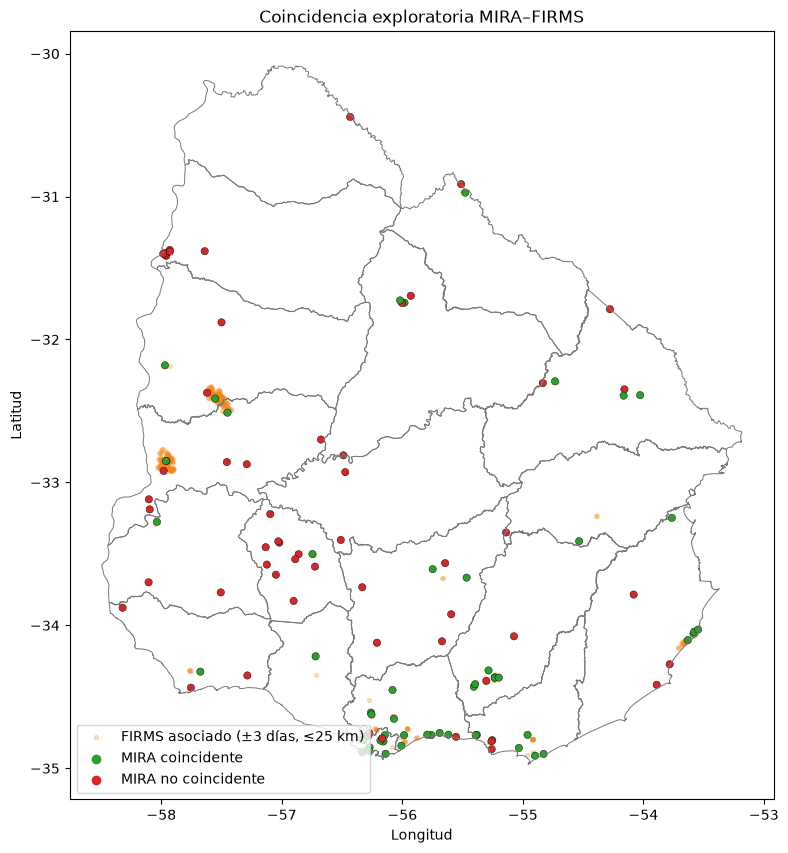

In [13]:
indices_firms_referencia = pares.loc[pares["diferencia_dias"].abs().le(3) & pares["distancia_km"].le(25), "indice_firms"].unique()
fig, ax = plt.subplots(figsize=(8, 9))
limites.boundary.plot(ax=ax, color="#777777", linewidth=0.7)
firms_comun.loc[indices_firms_referencia].plot.scatter(x="longitud", y="latitud", ax=ax, s=8, alpha=0.25, color="#f58518", label="FIRMS asociado (±3 días, ≤25 km)")
colores = mira_perfiles["coincide_referencia"].map({True: "#2ca02c", False: "#d62728"})
ax.scatter(mira_perfiles["x"], mira_perfiles["y"], c=colores, s=28, edgecolor="black", linewidth=0.3)
ax.scatter([], [], c="#2ca02c", label="MIRA coincidente")
ax.scatter([], [], c="#d62728", label="MIRA no coincidente")
ax.set(title="Coincidencia exploratoria MIRA–FIRMS", xlabel="Longitud", ylabel="Latitud")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 9. Contraste agregado departamento–semanaEste cruce responde si una combinación departamento–semana con al menos un registro MIRA tiene conteo FIRMS positivo en el panel existente. No reemplaza el análisis punto a punto.

In [14]:
panel_firms = pd.read_parquet(RUTA_FIRMS_SEMANAL)
panel_firms["fecha_inicio_semana"] = pd.to_datetime(panel_firms["fecha_inicio_semana"], errors="raise")
panel_firms["departamento_normalizado"] = panel_firms["departamento"].map(normalizar_departamento)
semanas_mira = mira_comun[["departamento_normalizado", "fecha_inicio_semana"]].drop_duplicates()
contraste_semanal = semanas_mira.merge(
    panel_firms[["departamento_normalizado", "fecha_inicio_semana", "cantidad_detecciones"]],
    on=["departamento_normalizado", "fecha_inicio_semana"], how="left", validate="one_to_one")
assert contraste_semanal["cantidad_detecciones"].notna().all()
resumen_semanal = pd.Series({
    "departamento_semanas_con_MIRA": len(contraste_semanal),
    "FIRMS_igual_0": int(contraste_semanal["cantidad_detecciones"].eq(0).sum()),
    "FIRMS_mayor_0": int(contraste_semanal["cantidad_detecciones"].gt(0).sum()),
    "porcentaje_FIRMS_positivo": contraste_semanal["cantidad_detecciones"].gt(0).mean() * 100,
})
display(resumen_semanal.to_frame("valor").round(2))

,valor
departamento_semanas_con_MIRA,75.00
FIRMS_igual_0,29.00
FIRMS_mayor_0,46.00
porcentaje_FIRMS_positivo,61.33


## 10. Alcance de la evidencia

- FIRMS detecta anomalías térmicas; no identifica automáticamente incendios confirmados.
- MIRA contiene incendios registrados, pero este CSV presenta cobertura aparentemente incompleta y mezcla fuentes `sgsp`, `cecoed` y `prensa`.
- Una coincidencia MIRA–FIRMS aporta evidencia de consistencia entre las fuentes bajo el escenario definido.
- Una coincidencia alta no demuestra que todas las detecciones FIRMS correspondan a incendios.
- Una detección FIRMS sin MIRA no debe llamarse falso positivo: MIRA no puede tratarse como inventario exhaustivo.
- Un evento MIRA sin FIRMS no implica automáticamente un error de FIRMS; intervienen resolución satelital, nubosidad, horario, duración, tamaño y localización del evento.

## 11. Conclusiones

1. Los **113 registros MIRA** están dentro del período FIRMS. En el mismo departamento, 38 (33,63%) coinciden el mismo día, 54 (47,79%) en ±1 día, 76 (67,26%) en ±3 días y 82 (72,57%) en ±7 días; 73 (64,60%) coinciden en la misma semana.
2. Al exigir proximidad espacial la coincidencia baja: 7 eventos (6,19%) para mismo día/≤1 km, 17 (15,04%) para mismo día/≤5 km, 22 (19,47%) para mismo día/≤10 km y 55 (48,67%) para ±3 días/≤25 km.
3. El escenario más amplio solicitado, ±7 días/≤25 km, alcanza 62 eventos (54,87%). Ofrece la mayor consistencia numérica, pero también la menor especificidad espacial-temporal entre los escenarios y no puede llamarse el criterio verdadero. ±3 días/≤25 km se usa solo como referencia descriptiva intermedia.
4. Con esa referencia, coinciden 11/13 registros de `prensa` (84,62%), 19/38 de `cecoed` (50,00%) y 25/62 de `sgsp` (40,32%). Por tipo: 24/55 `De_Campo`, 18/33 `Interface_Urbana`, 12/24 `Forestal_Plantado` y 1/1 `Forestal_Nativo`. Las diferencias son descriptivas y los tamaños de algunos grupos son muy pequeños.
5. MIRA puede utilizarse como **contraste externo parcial** de FIRMS, porque aporta registros independientes y coordenadas comparables.
6. Existe evidencia de consistencia para una fracción apreciable de eventos, pero no para tratar MIRA como verdad de referencia exhaustiva. La cobertura temporal y el proceso de validación de sus fuentes no están documentados en el CSV.
7. Sin un inventario completo y validado no pueden estimarse sensibilidad, especificidad, falsos positivos ni falsos negativos. Además, existen incertidumbres temporales, diferencias de resolución y tres discrepancias departamentales más un punto MIRA fuera de los polígonos por `within`, documentados en el análisis de viabilidad anterior.